# **EDA Notebook**



---
## 0. Setup Environment

### 0.a Install Mandatory Packages

> Do not modify this code before running it

In [83]:
# Do not modify this code

import os
import sys
from pathlib import Path

COURSE = "36106"
ASSIGNMENT = "AT3"
DATA = "data"

asgmt_path = f"{COURSE}/assignment/{ASSIGNMENT}"
root_path = "./"

#print("###### Install required Python packages ######")
! pip install -q -r https://raw.githubusercontent.com/aso-uts/labs_datasets/main/36106-mlaa/requirements.txt

if os.getenv("COLAB_RELEASE_TAG"):

    from google.colab import drive
    from pathlib import Path

    #print("\n###### Connect to personal Google Drive ######")
    gdrive_path = "/content/gdrive"
    drive.mount(gdrive_path)
    root_path = f"{gdrive_path}/MyDrive/"

print("\n###### Setting up folders ######")
folder_path = Path(f"{root_path}/{asgmt_path}/") / DATA
folder_path.mkdir(parents=True, exist_ok=True)
print(f"\nYou can now save your data files in: {folder_path}")

if os.getenv("COLAB_RELEASE_TAG"):
    %cd {folder_path}

from IPython.display import display, HTML

def print_tile(key, value, size="h1"):
  return display(HTML(f"""<p style="color:grey">{key}</p><{size} font-size: 3em>{value}</{size}>"""))

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).

###### Setting up folders ######

You can now save your data files in: /content/gdrive/MyDrive/36106/assignment/AT3/data
/content/gdrive/MyDrive/36106/assignment/AT3/data


### 0.b Disable Warnings Messages

> Do not modify this code before running it

In [84]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

### 0.c Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

In [ ]:
# <Student to fill this section>

### 0.d Import Packages

In [85]:
# <Student to fill this section>
import pandas as pd
import altair as alt
import numpy as np

---
## A. Project Description


In [ ]:
# <Student to fill this section>
group_name = "18"
student_name = "Laura Pacheco"
student_id = "25940875"

In [ ]:
# Do not modify this code
print_tile(size="h1", key='group_name', value=group_name)

In [ ]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [ ]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## B. Data Understanding

### B.1   Load Dataset

In [86]:
# Do not modify this code
try:
  df = pd.read_csv(folder_path / "customer_usage.csv")
except Exception as e:
  print(e)

### B.2 Explore Dataset

> You can add more cells in this section

In [87]:
df.head()

,Unnamed: 0,customer_id,avg_monthly_international_charges,avg_monthly_download_in_gb,monthly_charge,total_charges,total_refunds,total_extra_data_charges,total_international_charges,total_revenue
0,0,8070f82c-0fd5-447d-af80-722f9e80ec11,6.34,28,50.20,109.25,0.0,10.0,12.68,NaN
1,1,808e58b1-fa33-4794-97c6-0945a84d8bcf,49.00,23,95.70,1184.00,0.0,0.0,NaN,NaN
2,2,ed410e66-1d0a-4f14-af27-e2fd2d1ce56b,30.75,3,114.05,8468.20,0.0,0.0,2214.00,10682.20
3,3,236dab4c-b494-4eab-84cf-1a29a84c3707,0.00,28,41.95,2965.75,0.0,0.0,0.00,2965.75
4,4,4f55959e-6f73-4c9e-9b8b-4abb584a0e31,41.78,0,19.30,228.75,0.0,0.0,501.36,NaN


In [ ]:
df.shape

(11125, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11125 entries, 0 to 11124
Data columns (total 10 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         11125 non-null  int64  
 1   customer_id                        11125 non-null  object 
 2   avg_monthly_international_charges  11125 non-null  float64
 3   avg_monthly_download_in_gb         11125 non-null  int64  
 4   monthly_charge                     11125 non-null  float64
 5   total_charges                      10834 non-null  float64
 6   total_refunds                      10611 non-null  float64
 7   total_extra_data_charges           10858 non-null  float64
 8   total_international_charges        9142 non-null   float64
 9   total_revenue                      8302 non-null   float64
dtypes: float64(7), int64(2), object(1)
memory usage: 869.3+ KB


In [80]:
df.describe()

,Unnamed: 0,avg_monthly_international_charges,avg_monthly_download_in_gb,monthly_charge,total_charges,total_refunds,total_extra_data_charges,total_international_charges,total_revenue
count,11125.000000,11125.000000,11125.000000,11125.000000,10834.000000,10611.000000,10858.000000,9142.000000,8302.000000
mean,5562.000000,22.954817,20.831820,64.949209,2301.388563,2.107321,6.779333,752.907859,3025.000251
std,3211.655207,15.470966,20.472292,29.861493,2273.298339,8.265063,24.858582,853.474175,2837.747243
min,0.000000,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,21.400000
25%,2781.000000,9.200000,4.000000,39.100000,402.925000,0.000000,0.000000,66.560000,617.297500
50%,5562.000000,22.890000,17.000000,70.300000,1412.150000,0.000000,0.000000,406.030000,2135.730000
75%,8343.000000,36.390000,27.000000,89.950000,3865.562500,0.000000,0.000000,1199.965000,4720.810000
max,11124.000000,49.990000,85.000000,118.750000,8684.800000,49.570000,150.000000,3564.720000,11979.340000


In [ ]:
# Missing values per column
missing_counts = df.isnull().sum()

# Displaying missing counts
print("Missing values per column:")
print(missing_counts[missing_counts > 0])

Missing values per column:
total_charges                   291
total_refunds                   514
total_extra_data_charges        267
total_international_charges    1983
total_revenue                  2823
dtype: int64


In [89]:
columns_to_check = df.columns.difference(['customer_id', 'Unnamed: 0'])
duplicate_subset = df[df.duplicated(subset=columns_to_check, keep=False)]

print(f"Duplicate rows (excluding IDs): {len(duplicate_subset)}")
duplicate_subset.head()

Duplicate rows (excluding IDs): 5654


,Unnamed: 0,customer_id,avg_monthly_international_charges,avg_monthly_download_in_gb,monthly_charge,total_charges,total_refunds,total_extra_data_charges,total_international_charges,total_revenue
1,1,808e58b1-fa33-4794-97c6-0945a84d8bcf,49.00,23,95.70,1184.00,0.0,0.0,NaN,NaN
4,4,4f55959e-6f73-4c9e-9b8b-4abb584a0e31,41.78,0,19.30,228.75,0.0,0.0,501.36,NaN
6,6,453a806f-a904-414b-b7d2-e7e27e1d2f54,36.81,16,86.25,181.65,0.0,0.0,73.62,NaN
7,7,218749e6-2975-41f7-a3e1-ab5f2ab0f64f,16.22,12,104.75,4323.45,0.0,0.0,681.24,5004.69
8,8,98cf990e-9a1f-4851-880f-fb872971c746,5.93,19,106.50,7397.00,0.0,0.0,NaN,NaN


In [ ]:
# <Student to fill this section>
dataset_insights = dataset_insights = """The dataset includes 11,125 records and 10 columns, each row representing a unique telecom customer.

Most features are numerical, supporting use of unsupervised anomaly detection techniques.

Data shows significant variance in financial metrics:
  - total_revenue ranges from $21.40 to $11,979.34
  - total_international_charges spans $0 to $3,564.72

Median monthly charge is approximately $70, with values ranging from $18.25 to $118.75.

Data usage varies from 0 to 85 GB, with some high-charge but low-usage users indicating potential anomalies.

Missing data is present:
  - total_charges: 291 missing values (out of 11,125)
  - total_refunds: 514 missing values
  - total_extra_data_charges: 267 missing values
  - total_international_charges: 1,983 missing values
  - total_revenue: 2,823 missing values
Duplicated values: 5654
  """

In [ ]:
# Do not modify this code
print_tile(size="h3", key='dataset_insights', value=dataset_insights)

### B.3 Explore Feature of Interest 1

> You can add more cells in this section

In [106]:
# <Student to fill this section>
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
selected_features = selector.fit_transform(df.drop(columns=['customer_id']))

variances = df.drop(columns=['customer_id']).var()
print(variances.sort_values())

total_refunds                        6.831127e+01
avg_monthly_international_charges    2.393508e+02
avg_monthly_download_in_gb           4.191147e+02
total_extra_data_charges             6.179491e+02
monthly_charge                       8.917088e+02
total_international_charges          7.284182e+05
total_charges                        5.167885e+06
total_revenue                        8.052809e+06
Unnamed: 0                           1.031473e+07
dtype: float64


In [ ]:
# <Student to fill this section>
feature1_insights = """
I used the VarianceThreshold method from Scikit-learn to find and remove features with very low variance,
as they don’t help in detecting unusual patterns. The results showed that all key numerical features such as total_refunds,
avg_monthly_international_charges, monthly_charge, and total_revenue, had enough variation to be useful.
Among them, total_refunds had the lowest variance (68.31), while total_revenue and total_charges had the highest (over 8 million and 5 million),
which suggests they can help identify customers with unusual financial behavior. One column, Unnamed: 0, had high variance but was just an index
and might be removed. Based on this analysis, I chose eight features for the anomaly detection model:
total_refunds,
avg_monthly_international_charges,
avg_monthly_download_in_gb,
total_extra_data_charges,
monthly_charge,
total_international_charges,
total_charges, and total_revenue.
These features show meaningful differences in customer usage and spending, making them suitable for detecting anomalies using models
 like Isolation Forest.
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='feature1_insights', value=feature1_insights)

### B.4 Explore Feature of Interest 2

> You can add more cells in this section

In [ ]:
# <Student to fill this section>
num_cols = []

cat_cols = []

for col in df.columns:
    if df[col].dtype == 'int64' or df[col].dtype == 'float64':
        num_cols.append(col)
    else:
        cat_cols.append(col)

print("Numeric features:")
print(num_cols)
print(len(num_cols))

print("\nCategorical features:")
print(cat_cols)
print(len(cat_cols))

Numeric features:
['Unnamed: 0', 'avg_monthly_international_charges', 'avg_monthly_download_in_gb', 'monthly_charge', 'total_charges', 'total_refunds', 'total_extra_data_charges', 'total_international_charges', 'total_revenue']
9

Categorical features:
['customer_id']
1


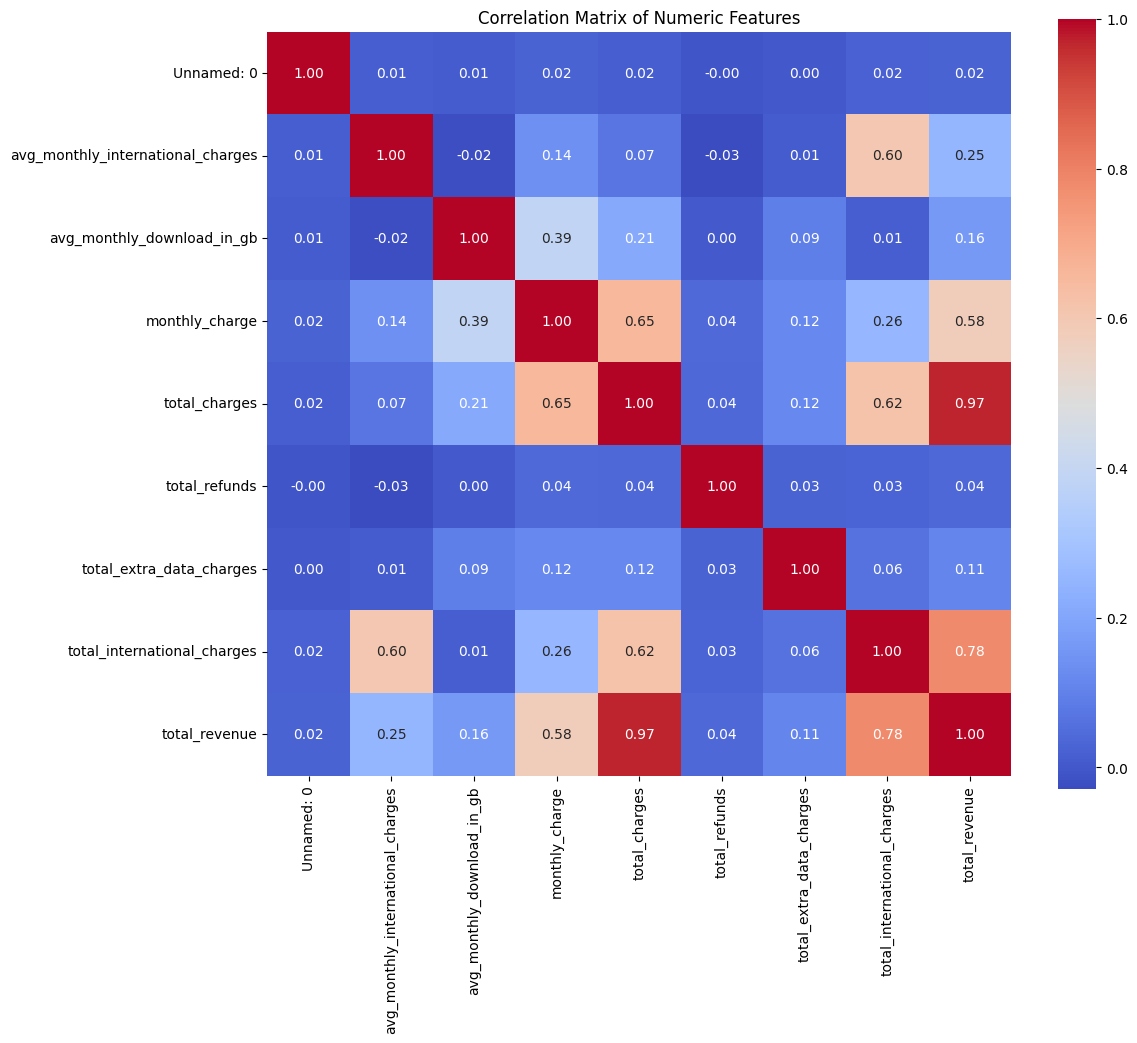

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

#numeric columns
corr_matrix = df[num_cols].corr()

# Plot
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Correlation Matrix of Numeric Features")
plt.show()

In [ ]:
# <Student to fill this section>
feature_2_insights = """
I used a correlation matrix (heatmap) to visually assess linear relationships between numeric features.
This approach helped identify pairs of highly correlated variables such as total_charges and total_revenue (r = 0.97),
and total_international_charges and total_revenue (r = 0.78). This method guided feature selection by highlighting redundancy,
allowing more informed decisions rather than automatically removing features based on a strict correlation threshold.

To avoid multicollinearity, and based on this method I should retained only total_international_charges from this group,
as it captures a more aspect of usage. Features such as avg_monthly_download_in_gb, avg_monthly_international_charges,
monthly_charge, total_refunds, and total_extra_data_charges showed low or moderate correlation
with others and wwill be therefore selected for modeling. These variables are expected to help uncover unusual
usage patterns and financial behaviors relevant to detecting anomalies.
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### B.5 Explore Feature of Interest n

> You can add more cells in this section

In [108]:
# <Student to fill this section>
#MISSING VALUE RATIO

missing_rate = df.isnull().mean()
print("Missing value rate per feature:\n", missing_rate.sort_values())

threshold = 0.4

df_filtered = df.loc[:, missing_rate < threshold]

# Show dropped columns
dropped_cols = missing_rate[missing_rate >= threshold].index.tolist()
print("Dropped columns due to high missing rate:", dropped_cols)

Missing value rate per feature:
 Unnamed: 0                           0.000000
customer_id                          0.000000
avg_monthly_international_charges    0.000000
avg_monthly_download_in_gb           0.000000
monthly_charge                       0.000000
total_extra_data_charges             0.024000
total_charges                        0.026157
total_refunds                        0.046202
total_international_charges          0.178247
total_revenue                        0.253753
dtype: float64
Dropped columns due to high missing rate: []


In [ ]:
# <Student to fill this section>
feature_n_insights = """

A missing value rate analysis was conducted to identify incomplete features.
A threshold of 40% was used to determine whether any columns should be removed.
The results showed that all features had acceptable levels of completeness,
with no columns exceeding the threshold. The most affected column was total_revenue,
with a missing rate of 25.4%, followed by total_international_charges at 17.8%.
Since these values are within manageable limits, all features should be retained for further processing,
and missing values will be handled during the data cleaning stage.

"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='feature_n_insights', value=feature_n_insights)

---
## C. Data Cleaning

### C.1 Copy Dataset

In [109]:
# Do not modify this code
df_clean = df.copy()
try:
  df_clean = df.copy()
except Exception as e:
  print(e)

In [94]:
df_clean.head()

,Unnamed: 0,customer_id,avg_monthly_international_charges,avg_monthly_download_in_gb,monthly_charge,total_charges,total_refunds,total_extra_data_charges,total_international_charges,total_revenue
0,0,8070f82c-0fd5-447d-af80-722f9e80ec11,6.34,28,50.20,109.25,0.0,10.0,12.68,NaN
1,1,808e58b1-fa33-4794-97c6-0945a84d8bcf,49.00,23,95.70,1184.00,0.0,0.0,NaN,NaN
2,2,ed410e66-1d0a-4f14-af27-e2fd2d1ce56b,30.75,3,114.05,8468.20,0.0,0.0,2214.00,10682.20
3,3,236dab4c-b494-4eab-84cf-1a29a84c3707,0.00,28,41.95,2965.75,0.0,0.0,0.00,2965.75
4,4,4f55959e-6f73-4c9e-9b8b-4abb584a0e31,41.78,0,19.30,228.75,0.0,0.0,501.36,NaN


### C.2 Fixing "Missing Values"

> Provide some explanations on why you believe it is important to fix this issue and its impacts

> You can add more cells in this section

In [110]:
# <Student to fill this section>
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

total_charges                   291
total_refunds                   514
total_extra_data_charges        267
total_international_charges    1983
total_revenue                  2823
dtype: int64


In [111]:
cols_missing_values = [
    'total_charges',
    'total_refunds',
    'total_extra_data_charges',
    'total_international_charges',
    'total_revenue'
]

for col in cols_missing_values:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)

In [ ]:
# <Student to fill this section>
data_cleaning_1_explanations = """
To address missing values in numerical columns such as total_revenue and total_charges, median imputation was applied.
This method was chosen because it is robust to outliers and preserves the central tendency of the data without skewing the distribution.
It also avoids the risks of underestimating usage patterns that could occur if missing values were replaced with zero.

"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### C.3 Fixing "Duplicated Values"

> Provide some explanations on why you believe it is important to fix this issue and its impacts

> You can add more cells in this section

In [112]:
duplicate_rows = df_clean[df_clean.duplicated(keep=False)]
print(f"Total duplicate rows found: {len(duplicate_rows)}")

print("\nExample duplicate rows:")
display(duplicate_rows.head())


df_clean = df_clean.drop_duplicates()
print(f"\nRemaining rows after removing duplicates: {df_clean.shape[0]}")

Total duplicate rows found: 0

Example duplicate rows:


,Unnamed: 0,customer_id,avg_monthly_international_charges,avg_monthly_download_in_gb,monthly_charge,total_charges,total_refunds,total_extra_data_charges,total_international_charges,total_revenue



Remaining rows after removing duplicates: 11125


In [113]:
# <Student to fill this section>
data_cleaning_2_explanations = """
Duplicated values were identify on section B.2 and dropped in section B.3.1.
duplicated values were removed before applying feature selection as they can mislead the learning algorithm
Inflate feature importance from repeated patterns
"""

In [99]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

### C.4 Fixing "Irrelevant Columns"

> Provide some explanations on why you believe it is important to fix this issue and its impacts

> You can add more cells in this section

In [114]:
df_clean.drop(columns=["Unnamed: 0","customer_id"], inplace=True, errors='ignore')

In [100]:
# <Student to fill this section>
data_cleaning_3_explanations = """
unnamed columna has no meaningful information and does not contribute
to any customer behavior pattern.
Customer_id: is a categorical identifier, not a numerical feature.
represents a unique value for each row, which confuses anomaly detection algorithms.
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_3_explanations', value=data_cleaning_3_explanations)

---
## D. Feature Engineering

### D.1 Copy Datasets

In [115]:
# Do not modify this code
try:
  df_eng = df_clean.copy()
except Exception as e:
  print(e)

### D.2 New Feature "International usage ratio"

> Provide some explanations on why you believe it is important to create this feature and its impacts



In [116]:
# <Average international charges per month>
df_eng["intl_usage_ratio"] = df_eng["total_international_charges"] / (df_eng["monthly_charge"] + 1)
print(df_eng["intl_usage_ratio"].describe())

count    11125.000000
mean        13.207856
std         19.953959
min          0.000000
25%          1.800215
50%          6.006361
75%         17.190280
max        174.705882
Name: intl_usage_ratio, dtype: float64


In [ ]:
# <Student to fill this section>
feature_engineering_1_explanations = """
 the average ratio is around 13.2, some customers exceed 170,
 suggesting extreme cases that may indicate fraudulent international usage, billing errors,
 or high-value corporate users.
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### D.3 New Feature "data_overuse_ratio"

> Add blockquote



> Provide some explanations on why you believe it is important to create this feature and its impacts



In [103]:
# <Student to fill this section>
df_eng["data_overuse_ratio"] = df_eng["total_extra_data_charges"] / (df_eng["monthly_charge"] + 1)

In [ ]:
# <Student to fill this section>
feature_engineering_2_explanations = """
 This new feature will measure how much extra data a customer uses in relation to their base monthly charge.
 This ratio can help identify dissatisfaction, plan not suitable, or unusual data activity.
 Customers with extreme ratios would be candidates for Customer Support follow-up or fraud investigation.
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

### D.4 New Feature "Refund_ratio>"

> Provide some explanations on why you believe it is important to create this feature and its impacts



In [104]:
# <Student to fill this section>
df_eng["refund_ratio"] = df_eng["total_refunds"] / (df_eng["total_charges"] + 1)
print(df_eng["refund_ratio"].describe())

count    11125.000000
mean         0.001705
std          0.010110
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.189417
Name: refund_ratio, dtype: float64


In [ ]:
# <Student to fill this section>
feature_engineering_3_explanations = """
The refund_ratio feature captures the share of charges that were refunded to the customer.
A high ratio may signal dissatisfaction, complaints, or billing errors.
the majority of customers (75% of the data is at or below 0.0, meaning at least 75% of customers received no refunds at all.) received no refunds,
indicating generally the billing was correct. However, a small number of customers exhibit refund ratios nearing 18.94%,
which may suggest serious service dissatisfaction, billing issues. These cases are candidates for escalation to the Customer Support team.
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_3_explanations', value=feature_engineering_3_explanations)

---
## E. Save Datasets

In [117]:
# <Student to fill this section>
df_eng.to_csv("df_customer_usage_cleaned.csv", index=False)
print(df_eng.head())


   avg_monthly_international_charges  avg_monthly_download_in_gb  \
0                               6.34                          28   
1                              49.00                          23   
2                              30.75                           3   
3                               0.00                          28   
4                              41.78                           0   

   monthly_charge  total_charges  total_refunds  total_extra_data_charges  \
0           50.20         109.25            0.0                      10.0   
1           95.70        1184.00            0.0                       0.0   
2          114.05        8468.20            0.0                       0.0   
3           41.95        2965.75            0.0                       0.0   
4           19.30         228.75            0.0                       0.0   

   total_international_charges  total_revenue  intl_usage_ratio  
0                        12.68        2135.73          0.24765